# Exploração de Dispositivos

Este notebook processa a base de dados massiva de simulações e gera insights visuais sobre o comportamento individual de cada dispositivo (`sta0`, `sta1`, ...). Os dados são extraídos a nível de **experimento (CSV)**: para cada rodada calculamos a média do tempo de treinamento, o máximo de consumo e a frequência absoluta de seleção.

In [23]:
import os
import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Configuração de estilo dos gráficos
sns.set_theme(style="whitegrid", font_scale=1.1)

## 1. Processamento por Rodada (Média dos CSVs)
Em vez de concatenar todas as iterações de todos os CSVs de uma vez, nós agregamos os dados **por arquivo (experimento)**. Isso evita que metodologias com mais CSVs ou que demorem mais iterações para convergir distorçam os totais.

In [24]:
base_path = '.'
data_frames = []

for dist_folder in ['iid', 'non_iid']:
    dist_path = os.path.join(base_path, dist_folder)
    if not os.path.exists(dist_path):
        continue
        
    subfolders = [f for f in os.listdir(dist_path) if os.path.isdir(os.path.join(dist_path, f))]
    
    for folder in subfolders:
        norm_folder = folder.replace('-', '_')
        
        if norm_folder.startswith('iid_'):
            distribution = 'IID'
        elif norm_folder.startswith('non_iid_'):
            distribution = 'Non-IID'
        else:
            continue
            
        if norm_folder.endswith('_all'):
            methodology = 'Padrão'
        elif norm_folder.endswith('_leastEnergy'):
            methodology = 'LeastEnergy'
        elif norm_folder.endswith('_afea'):
            methodology = 'AFEA'
        elif norm_folder.endswith('_afea_2'):
            methodology = 'AFEA 2'
        else:
            continue
            
        csv_files = glob.glob(os.path.join(dist_path, folder, '*metrics*.csv'))
        for i, csv_file in enumerate(csv_files):
            try:
                rodada = int(csv_file.split('_')[-1].replace('.csv', ''))
            except ValueError:
                rodada = i + 1
                
            df_temp = pd.read_csv(csv_file)
            training_cols = [c for c in df_temp.columns if c.startswith('training_time_sta')]
            
            for t_col in training_cols:
                sta_id = t_col.replace('training_time_', '')
                cons_col = f'consumption_{sta_id}'
                
                if cons_col in df_temp.columns:
                    valid_mask = pd.notnull(df_temp[t_col])
                    frequencia = valid_mask.sum()
                    
                    if frequencia > 0:
                        tempo_medio = df_temp.loc[valid_mask, t_col].mean()
                        consumo_total = df_temp.loc[valid_mask, cons_col].max()
                    else:
                        tempo_medio = None
                        consumo_total = df_temp[cons_col].max() if pd.notnull(df_temp[cons_col].max()) else 0
                    
                    data_frames.append({
                        'Distribuição': distribution,
                        'Metodologia': methodology,
                        'Rodada': rodada,
                        'Dispositivo': sta_id,
                        'Frequência de Seleção': frequencia,
                        'Tempo de Treinamento': tempo_medio,
                        'Consumo Acumulado': consumo_total
                    })

df_experimentos = pd.DataFrame(data_frames)
df_experimentos['Dispositivo_Num'] = df_experimentos['Dispositivo'].apply(lambda x: int(x.replace('sta', '')) if 'sta' in x else 999)
df_experimentos = df_experimentos.sort_values(by=['Distribuição', 'Dispositivo_Num'])

print(f"Foram agregados dados de {len(df_experimentos)} instâncias (Dispositivo em uma Rodada específica).")

Foram agregados dados de 573 instâncias (Dispositivo em uma Rodada específica).


## 2. Frequência de Seleção
Média da quantidade de vezes que o dispositivo foi selecionado por experimento.

O *barplot* do Seaborn agora plota automaticamente a média entre as rodadas e inclui barras de erro (intervalo de confiança).

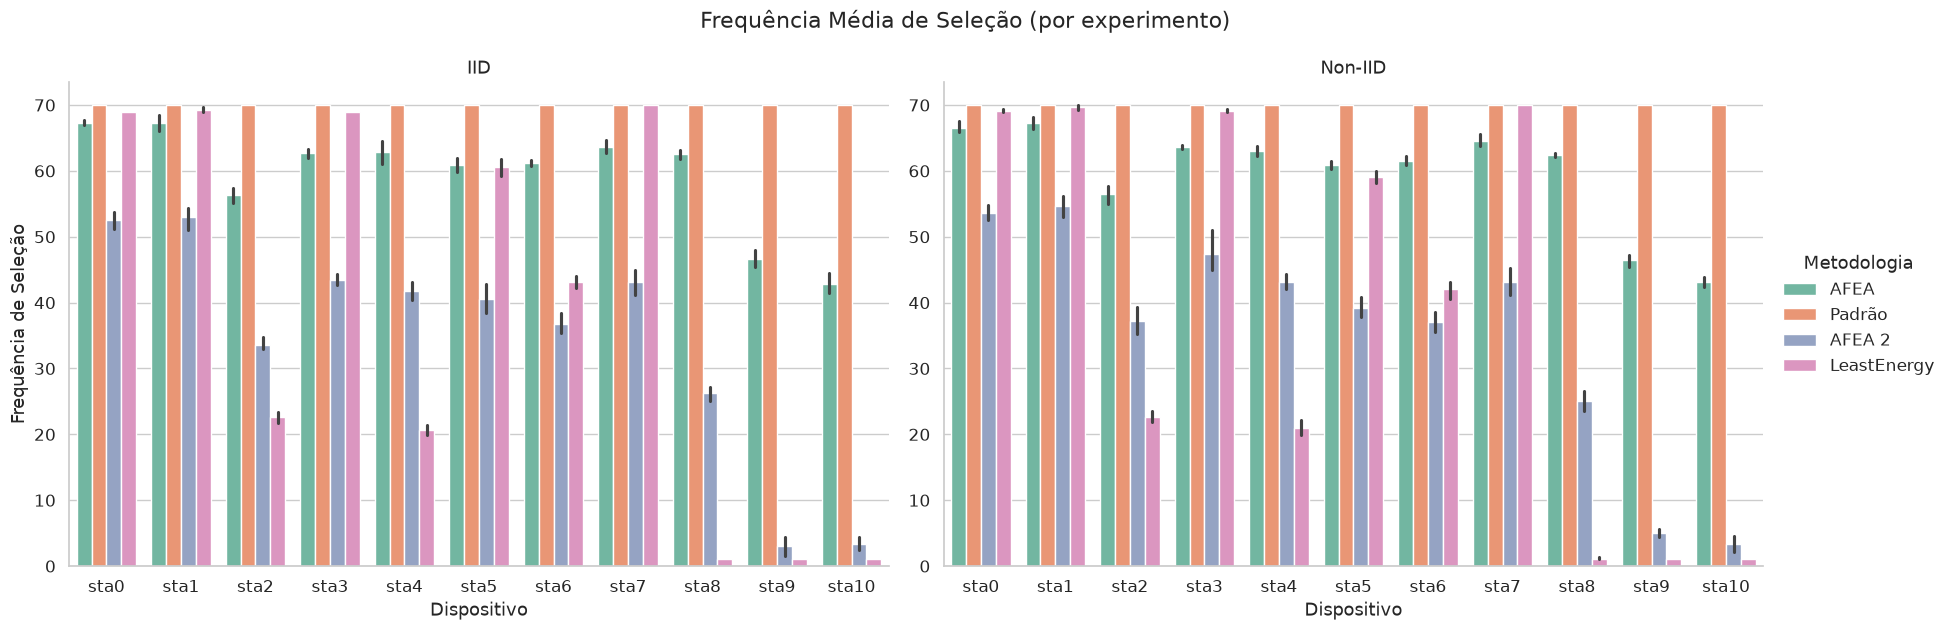

In [25]:
g1 = sns.catplot(
    data=df_experimentos,
    x='Dispositivo',
    y='Frequência de Seleção',
    hue='Metodologia',
    col='Distribuição',
    kind='bar',
    height=6,
    aspect=1.5,
    palette='Set2',
    sharey=False
)
g1.fig.suptitle('Frequência Média de Seleção (por experimento)', y=1.05, fontsize=16)
g1.set_titles("{col_name}")
plt.show()

## 3. Tempo de Treinamento
Variação do **tempo médio de treinamento** que cada dispositivo teve em cada rodada.

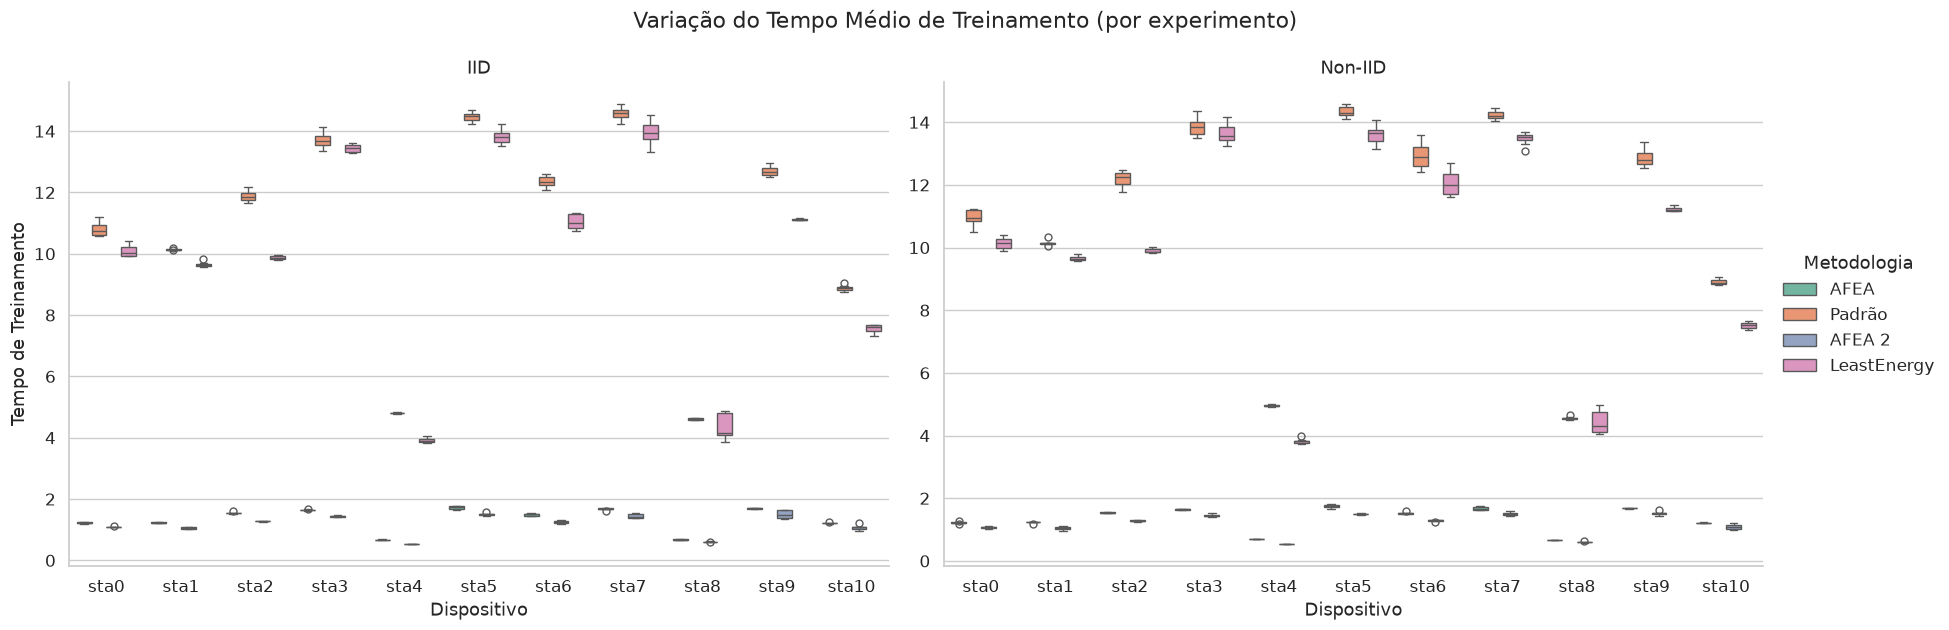

In [26]:
g2 = sns.catplot(
    data=df_experimentos,
    x='Dispositivo',
    y='Tempo de Treinamento',
    hue='Metodologia',
    col='Distribuição',
    kind='box',
    height=6,
    aspect=1.5,
    palette='Set2',
    sharey=False
)
g2.fig.suptitle('Variação do Tempo Médio de Treinamento (por experimento)', y=1.05, fontsize=16)
g2.set_titles("{col_name}")
plt.show()

## 4. Consumo Total/Acumulado
Impacto energético total alcançado ao final de cada experimento.

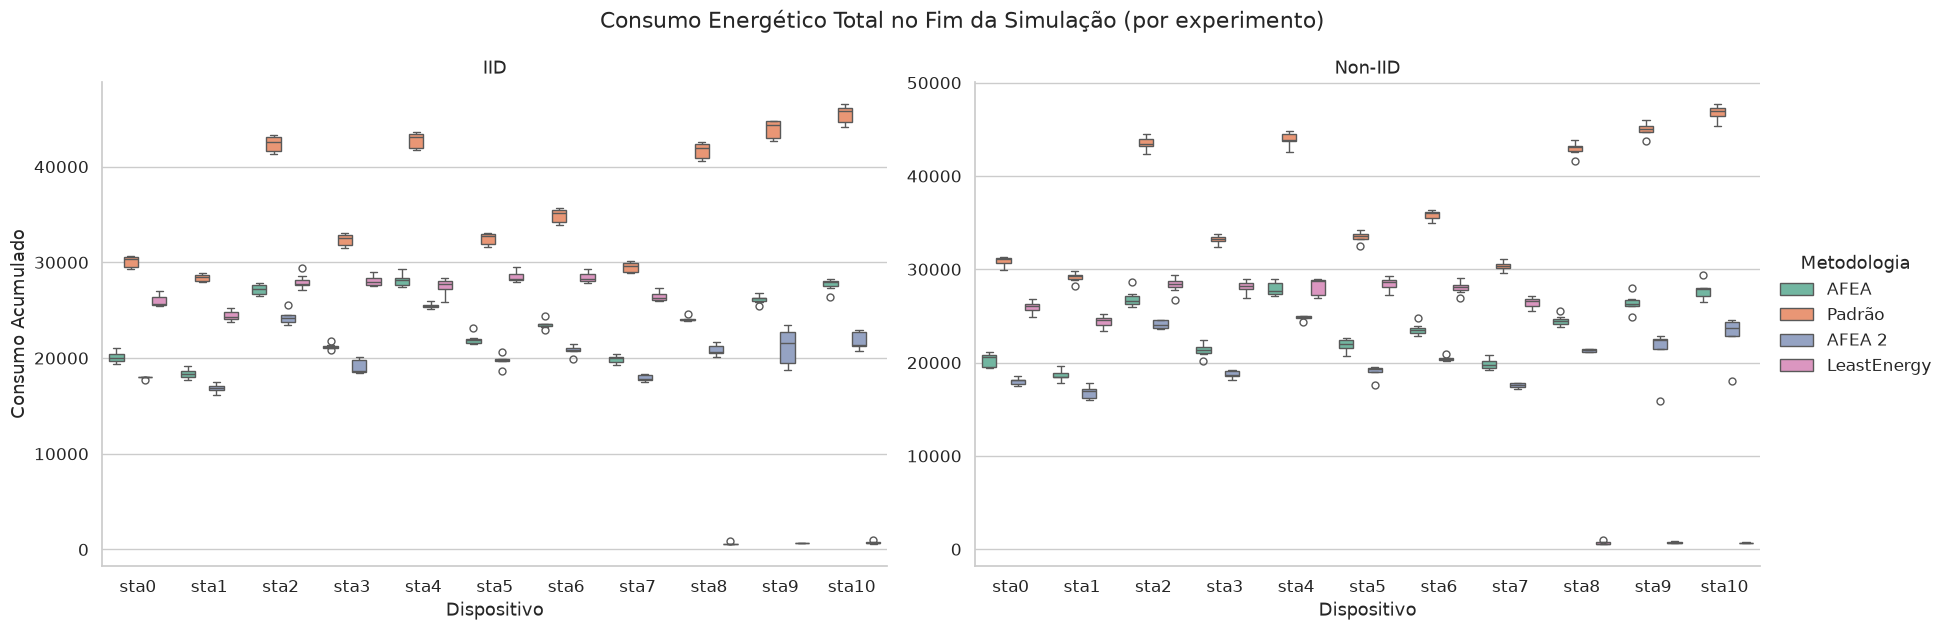

In [27]:
g3 = sns.catplot(
    data=df_experimentos,
    x='Dispositivo',
    y='Consumo Acumulado',
    hue='Metodologia',
    col='Distribuição',
    kind='box',
    height=6,
    aspect=1.5,
    palette='Set2',
    sharey=False
)
g3.fig.suptitle('Consumo Energético Total no Fim da Simulação (por experimento)', y=1.05, fontsize=16)
g3.set_titles("{col_name}")
plt.show()